# Financial Time serier

In [1]:
# import các thư viện cần thiết
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np

In [2]:
# nhập (import) module os trong Python, để tương tác với hệ điều hành (Operating System)
import os
# Kiểm tra thư mục làm việc hiện tại
print(os.getcwd())

D:\DH CÔNG NGHIỆP THỰC PHẨM\HK1 (25_26)_Lập trình hướng đối tượng\Lap trinh huong doi tuong\Code\Ch4


In [3]:
# Đọc file data.csv và chuyển thành DataFame với tên data
data = pd.read_csv('data.csv', index_col=0, parse_dates=True)

In [4]:
type (data)


pandas.core.frame.DataFrame

# Ở giai đoạn này, một nhà phân tích tài chính có lẽ sẽ thực hiện cái nhìn đầu tiên về dữ liệu, hoặc bằng cách kiểm tra trực tiếp hoặc bằng cách trực quan hóa nó

In [5]:
# Xem thông tin dữa liệu 
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2648 entries, 2023-01-03 to 2025-08-29
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    2648 non-null   float64
 1   high    2648 non-null   float64
 2   low     2648 non-null   float64
 3   close   2648 non-null   float64
 4   volume  2648 non-null   int64  
 5   Ticker  2648 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 144.8+ KB


In [6]:
# Xem 5 dòng đầu tiên của dữ liệu, mục đích: xem sơ bộ cấu trúc, biến số, kiểu dữ liệu, và 5 giá trị ban đầu.
data.head() 

,open,high,low,close,volume,Ticker
time,,,,,,
2023-01-03,53.8,56.8,53.4,56.8,2010563,VIC
2023-01-04,56.9,57.1,55.9,56.0,1930194,VIC
2023-01-05,56.1,56.9,55.8,56.2,1643187,VIC
2023-01-06,56.0,56.1,54.9,56.1,1952310,VIC
2023-01-09,56.2,56.2,55.0,55.0,1205370,VIC


In [7]:
# Hiển thị 5 dòng cuối cùng của Dta, mục đích: xem sơ bộ cấu trúc, biến số, kiểu dữ liệu, và 5 giá trị cuối.
data.tail()

,open,high,low,close,volume,Ticker
time,,,,,,
2025-08-25,1829.60,1830.92,1774.84,1783.12,714532383,VN30
2025-08-26,1783.00,1850.00,1772.39,1849.05,610788979,VN30
2025-08-27,1861.66,1877.27,1842.10,1848.55,684018941,VN30
2025-08-28,1854.31,1866.18,1831.79,1861.20,548866274,VN30
2025-08-29,1872.38,1880.06,1855.28,1865.38,679183869,VN30


In [8]:
# Thay đổi tên cột 
data = data.rename(columns={
    "open": "GIA_MOCUA",
    "close": "GIA_DONGCUA",
    "high": "GIA_CAO",
    "low": "GIA_THAP",
    "Ticker": "MA_CP",
    "volume":"KL_GD"
})


In [9]:
# Xem lại dữ liệu để kiểm tra đã thay đổi chưa
data.head()

,GIA_MOCUA,GIA_CAO,GIA_THAP,GIA_DONGCUA,KL_GD,MA_CP
time,,,,,,
2023-01-03,53.8,56.8,53.4,56.8,2010563,VIC
2023-01-04,56.9,57.1,55.9,56.0,1930194,VIC
2023-01-05,56.1,56.9,55.8,56.2,1643187,VIC
2023-01-06,56.0,56.1,54.9,56.1,1952310,VIC
2023-01-09,56.2,56.2,55.0,55.0,1205370,VIC


In [10]:
# Xóa cột không cần thiết và lưu vào data_1
data_1 = data.drop(columns=["GIA_MOCUA", "GIA_CAO", "GIA_THAP", "KL_GD"])

In [11]:
data_1.head()

,GIA_DONGCUA,MA_CP
time,,
2023-01-03,56.8,VIC
2023-01-04,56.0,VIC
2023-01-05,56.2,VIC
2023-01-06,56.1,VIC
2023-01-09,55.0,VIC


In [12]:
# Pivot để có time làm index, MA_CP làm cột, GIA_DONGCUA làm giá trị
data_wide = data_1.pivot_table(index=data_1.index, columns='MA_CP',values='GIA_DONGCUA', aggfunc='last') 
# aggfunc='last' chọn giá trị cuối cùng (last).
data_wide.index.name = 'time'

In [13]:
data_wide.head(10)

MA_CP,VIC,VN30,VNINDEX,VNM
time,,,,
2023-01-03,56.8,1047.25,1043.90,68.94
2023-01-04,56.0,1050.15,1046.35,69.64
2023-01-05,56.2,1061.90,1055.82,71.31
2023-01-06,56.1,1057.40,1051.44,70.08
2023-01-09,55.0,1061.14,1054.21,70.87
2023-01-10,54.5,1060.53,1053.35,71.14
2023-01-11,55.1,1065.22,1055.76,69.73
2023-01-12,55.0,1066.24,1056.39,70.26
2023-01-13,55.0,1069.86,1060.17,70.79


In [14]:
# luu thanh file CSV có tên data_wide.csv
data_wide.to_csv('data_wide.csv',encoding = 'utf-8-sig') # VCI_data.csv tên file csv
print (' da luu data_wide.csv')

 da luu data_wide.csv


In [15]:
# Hiển thị 5 dòng đầu tiên của dữ liệu , mục đích: xem sơ bộ cấu trúc, biến số, kiểu dữ liệu, và giá trị ban đầu.
data_wide.head() 

MA_CP,VIC,VN30,VNINDEX,VNM
time,,,,
2023-01-03,56.8,1047.25,1043.90,68.94
2023-01-04,56.0,1050.15,1046.35,69.64
2023-01-05,56.2,1061.90,1055.82,71.31
2023-01-06,56.1,1057.40,1051.44,70.08
2023-01-09,55.0,1061.14,1054.21,70.87


In [16]:
# Hiển thị 5 dòng cuối cùng của Dta, mục đích: xem sơ bộ cấu trúc, biến số, kiểu dữ liệu, và giá trị ban đầu.
data_wide.tail()

MA_CP,VIC,VN30,VNINDEX,VNM
time,,,,
2025-08-25,131.0,1783.12,1614.03,58.7
2025-08-26,135.5,1849.05,1667.63,59.7
2025-08-27,132.0,1848.55,1672.78,60.5
2025-08-28,130.1,1861.20,1680.86,61.0
2025-08-29,128.3,1865.38,1682.21,60.3


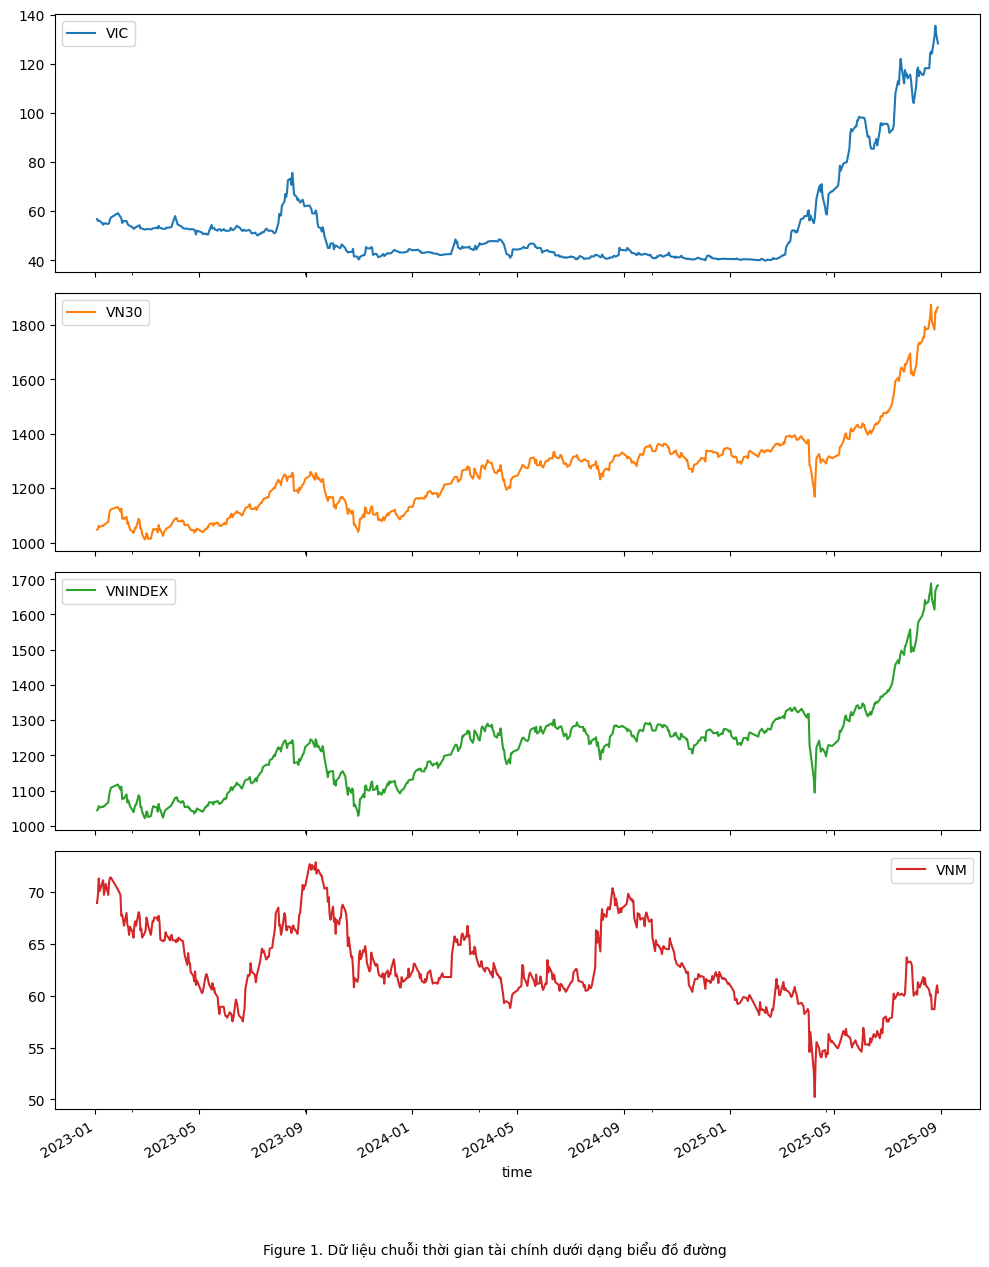

In [17]:
# Trực quan hóa toàn bộ tập dữ liệu thông qua nhiều biểu đồ con (subplots).
data_wide.plot(figsize=(10, 12), subplots=True);   # Vẽ toàn bộ các chuỗi thời gian trong data_wide.
                                    # Mỗi cột (mã cổ phiếu) sẽ được vẽ thành một biểu đồ con (subplot) riêng.
                                    # figsize=(10, 12) đặt kích thước figure rộng 10, cao 12 inch.
                                    # Giúp quan sát trực quan sự biến động giá của từng mã cổ phiếu theo thời gian.

# Thêm chú thích dưới cùng của figure (caption giải thích biểu đồ)
plt.figtext(0.5, -0.05,                      # Vị trí: x=0.5 (giữa), y=-0.05 (dưới trục x)
            "Figure 1. Dữ liệu chuỗi thời gian tài chính dưới dạng biểu đồ đường",  # Nội dung chú thích
            wrap=True,                       # Tự động xuống dòng nếu text quá dài
            horizontalalignment='center',    # Căn giữa chú thích theo chiều ngang
            fontsize=10)                     # Cỡ chữ = 10

# Điều chỉnh bố cục để tránh chồng chéo giữa các subplot và trục
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()


# Thống kê mô tả (tóm tắt)

In [18]:
data_wide.info() 

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 662 entries, 2023-01-03 to 2025-08-29
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   VIC      662 non-null    float64
 1   VN30     662 non-null    float64
 2   VNINDEX  662 non-null    float64
 3   VNM      662 non-null    float64
dtypes: float64(4)
memory usage: 25.9 KB


In [19]:
data_wide.describe().round(2)

MA_CP,VIC,VN30,VNINDEX,VNM
count,662.00,662.00,662.00,662.00
mean,54.57,1259.93,1223.12,62.66
std,20.13,160.23,123.42,4.00
min,39.90,1011.46,1021.25,50.22
25%,42.10,1125.36,1124.66,60.36
50%,46.48,1271.58,1237.93,62.00
75%,54.95,1330.88,1279.14,65.54
max,135.50,1874.91,1688.00,72.87


# Thay đổi theo thời gian (Changes over Time)
1- Thay đổi tuyệt đối

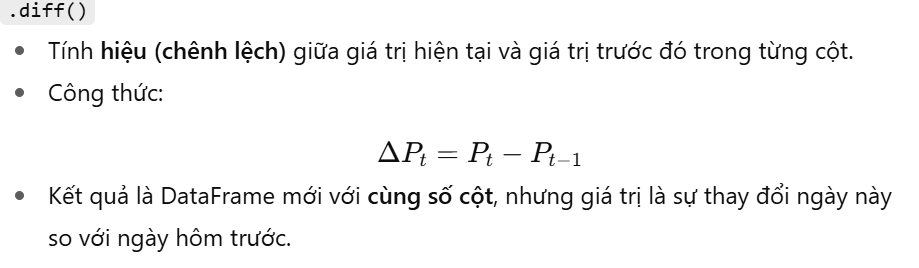

2- Thay đổi tương đối (lợi suât giản đơn)

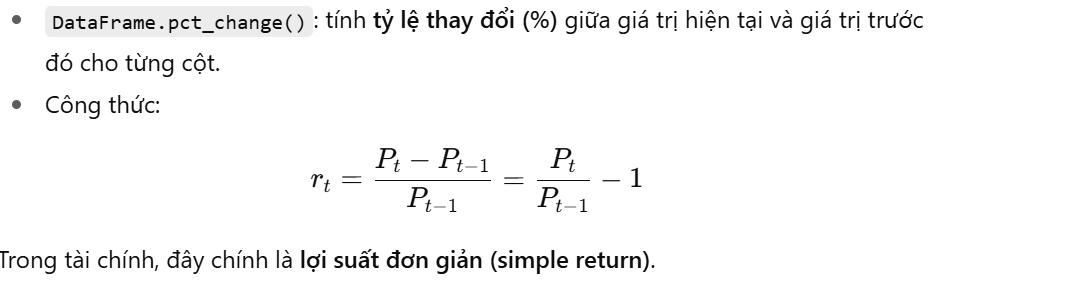

3- log return (lợi suất logarit).

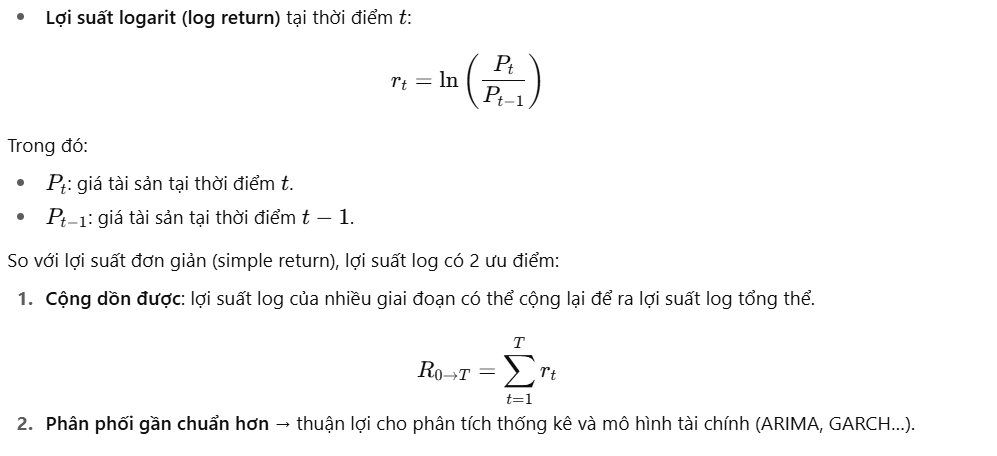

# 1. Thay đổi tuyệt đối

In [20]:
# Thay đổi tuyệt đối
# diff() Tính thay đổi tuyệt đối giữa hai chỉ mục (Trong dữ liệu là giữ hai phiên giao dịch)
data_wide.diff().head() # tính thay đổi tuyệt đối và hiện thị 5 dòng đầu tiên

MA_CP,VIC,VN30,VNINDEX,VNM
time,,,,
2023-01-03,NaN,NaN,NaN,NaN
2023-01-04,-0.8,2.90,2.45,0.70
2023-01-05,0.2,11.75,9.47,1.67
2023-01-06,-0.1,-4.50,-4.38,-1.23
2023-01-09,-1.1,3.74,2.77,0.79


In [21]:
# Tính giá cổ phiếu trung bình tăng/giảm bao nhiêu mỗi ngày.
data_wide.diff().mean() 

MA_CP
VIC        0.108169
VN30       1.237716
VNINDEX    0.965673
VNM       -0.013071
dtype: float64

From a statistics point of view, absolute changes are not optimal because they are
dependent on the scale of the time series data itself. Therefore, percentage changes
are usually preferred. The following code derives the percentage changes or percent‐
age returns (also: simple returns) in a financial context and visualizes their mean val‐
ues per column (see Figure 8-2):

# 2. Thay đổi tương đối (%)_ Lợi suất đơn giản

In [22]:
# Tính tỷ lệ thay đổi % giữa hai chỉ mục (Trong dữ liệu là giữ hai phiên giao dịch)
# Đây cũng chính là tích tỷ suất sinh lời phiên giao dịch này so với phiên giao dịch trước đó
data_wide.pct_change().head().round(3)

MA_CP,VIC,VN30,VNINDEX,VNM
time,,,,
2023-01-03,NaN,NaN,NaN,NaN
2023-01-04,-0.014,0.003,0.002,0.010
2023-01-05,0.004,0.011,0.009,0.024
2023-01-06,-0.002,-0.004,-0.004,-0.017
2023-01-09,-0.020,0.004,0.003,0.011


In [23]:
# Giá trị trung bình của các thay đổi phần trăm theo ngày
data_wide.pct_change().mean()

MA_CP
VIC        0.001461
VN30       0.000938
VNINDEX    0.000779
VNM       -0.000125
dtype: float64

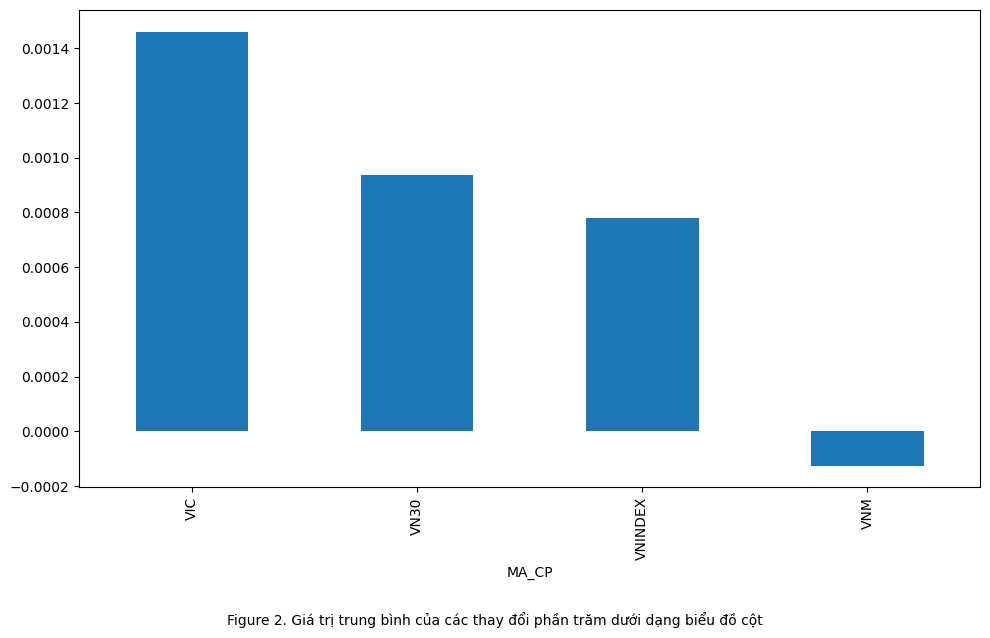

In [24]:
data_wide.pct_change().mean().plot(kind='bar', figsize=(10, 6))
# Thêm chú thích dưới cùng của figure
plt.figtext(0.5, -0.05,
            "Figure 2. Giá trị trung bình của các thay đổi phần trăm dưới dạng biểu đồ cột",
            wrap=True, horizontalalignment='center', fontsize=10)

plt.tight_layout()
plt.show()


# 3. log return (lợi suất logarit).

In [25]:
# Calculates the log returns in vectorized fashion.
#rets = np.log(data_wide / data_wide.shift(1))

In [26]:
rets = np.log(data_wide / data_wide.shift(1)).mean() 

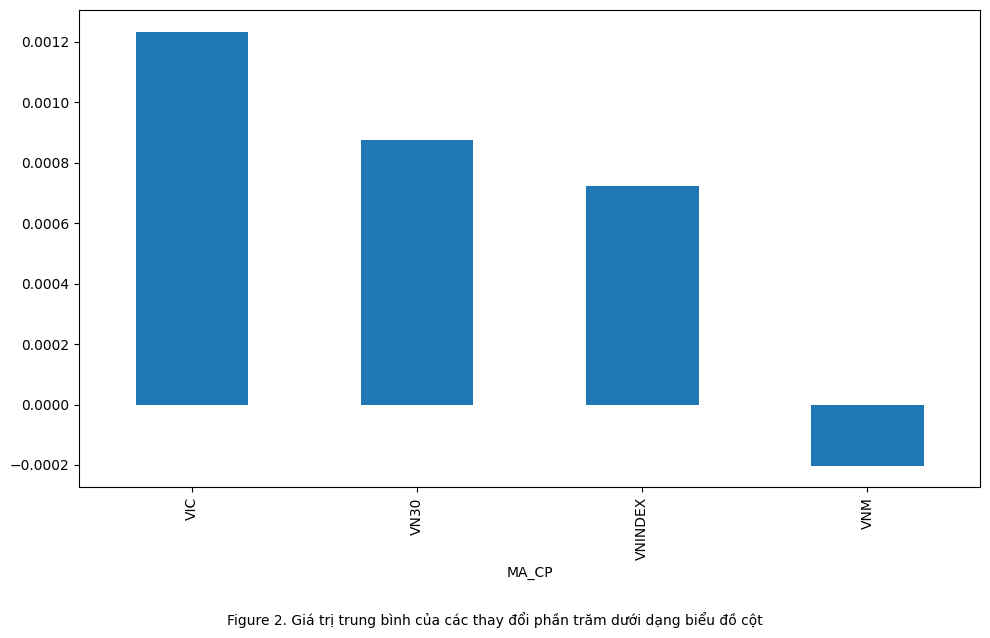

In [27]:
rets.plot(kind='bar', figsize=(10, 6))
# Thêm chú thích dưới cùng của figure
plt.figtext(0.5, -0.05,
            "Figure 2. Giá trị trung bình của các thay đổi phần trăm dưới dạng biểu đồ cột",
            wrap=True, horizontalalignment='center', fontsize=10)

plt.tight_layout()
plt.show()

In [28]:
# Xem kết quả 
rets.head().round(3)

MA_CP
VIC        0.001
VN30       0.001
VNINDEX    0.001
VNM       -0.000
dtype: float64

# Trực quan hóa lợi suất tích lũy
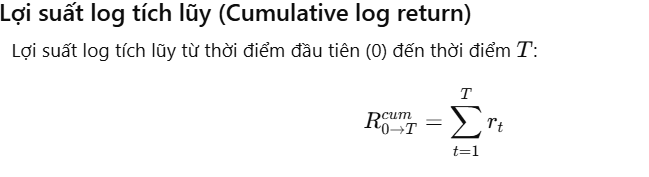

In [29]:
rets_1=rets.cumsum()

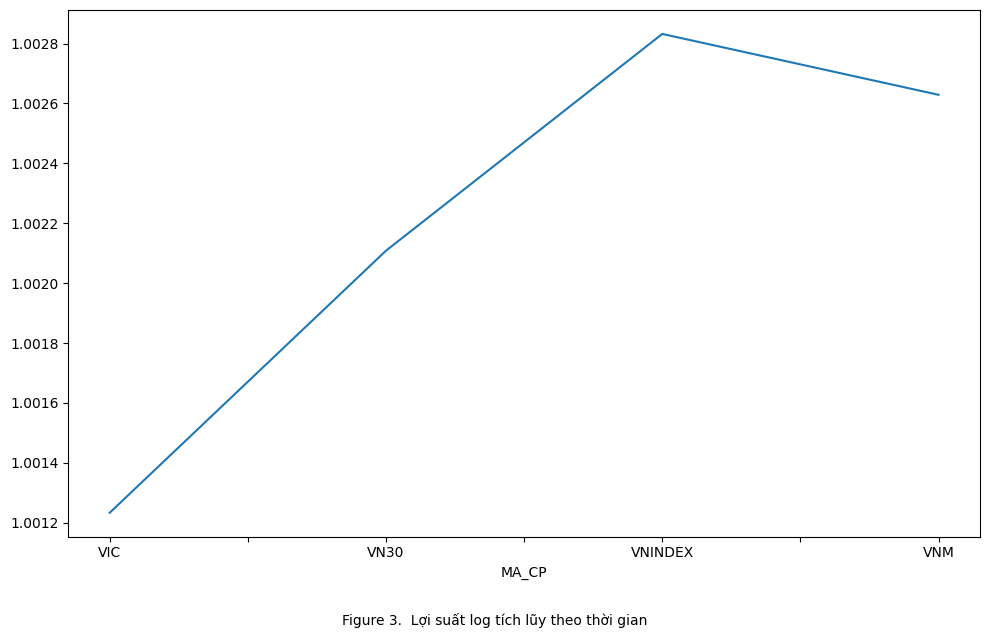

In [30]:
# trước tiên gọi phương thức cumsum() để tính tổng cộng dồn,sau đó áp dụng hàm np.exp() lên kết quả.
# Vẽ log return tích lũy theo thời gian
rets_1.apply(np.exp).plot(figsize=(10, 6));   # Vẽ log return tích lũy (cumulative log return).
                                            # rets.cumsum(): tính tổng cộng dồn log returns theo thời gian.
                                            # apply(np.exp): chuyển log return tích lũy về dạng tỷ lệ tăng trưởng.
                                            # plot(...): vẽ biểu đồ đường với kích thước (10,6).

# Thêm chú thích dưới cùng của figure
plt.figtext(0.5, -0.05,                              # Đặt vị trí chú thích: x=0.5 (giữa), y=-0.05 (dưới trục x).
            "Figure 3.  Lợi suất log tích lũy theo thời gian",   # Nội dung chú thích (caption cho hình).
            wrap=True, horizontalalignment='center', fontsize=10)  # wrap: xuống dòng nếu dài, căn giữa, cỡ chữ 10.

plt.tight_layout()                                   # Điều chỉnh bố cục để không bị chồng nhãn hoặc cắt chữ.
plt.show()                                           # Hiển thị biểu đồ ra màn hình.


# Resampling (Lấy lại mẫu)
Tái mẫu (Resampling) là một thao tác quan trọng đối với dữ liệu chuỗi thời gian tài chính. Thông thường, điều này xuất hiện dưới dạng giảm tần suất (downsampling), nghĩa là, ví dụ, một chuỗi dữ liệu tick được tái mẫu thành các khoảng thời gian một phút hoặc một chuỗi thời gian với các quan sát hằng ngày được tái mẫu thành chuỗi với các quan sát theo tuần hoặc theo tháng (như được minh họa).

Các dạng tái mẫu (Resampling)
1. Downsampling (giảm tần suất dữ liệu)
- Khái niệm: Chuyển dữ liệu từ tần suất cao → thấp hơn.
- Ví dụ:
Từ tick data (từng giao dịch) → dữ liệu 1 phút.
Từ dữ liệu hằng ngày → dữ liệu tuần hoặc tháng.
- Ứng dụng:
Phân tích xu hướng dài hạn (ví dụ: hiệu suất tháng, quý).
Giảm nhiễu (noise) trong dữ liệu.
2. Upsampling (tăng tần suất dữ liệu)
- Khái niệm: Chuyển dữ liệu từ tần suất thấp → cao hơn.
- Ví dụ:
Từ dữ liệu tuần → dữ liệu ngày.
Từ dữ liệu tháng → dữ liệu ngày.
- Ứng dụng:
Chuẩn hóa tần suất để kết hợp với chuỗi khác.
Dùng cho mô hình mô phỏng.

In [31]:
# Dữ được lấy mẫu lại theo khoảng thời gian hàng tuần...
data_wide.resample('W', label='right').last().head()

MA_CP,VIC,VN30,VNINDEX,VNM
time,,,,
2023-01-08,56.1,1057.40,1051.44,70.08
2023-01-15,55.0,1069.86,1060.17,70.79
2023-01-22,57.4,1121.92,1108.08,71.40
2023-01-29,59.2,1130.65,1117.10,70.26
2023-02-05,56.0,1085.70,1077.15,66.75


In [32]:
#  and monthly time intervals
data_wide.resample('ME', label='right').last().head() 

MA_CP,VIC,VN30,VNINDEX,VNM
time,,,,
2023-01-31,57.1,1125.07,1111.18,67.71
2023-02-28,52.6,1014.96,1024.68,66.31
2023-03-31,55.0,1073.68,1064.64,65.34
2023-04-30,52.1,1051.43,1049.12,61.48
2023-05-31,52.0,1066.33,1075.17,58.05


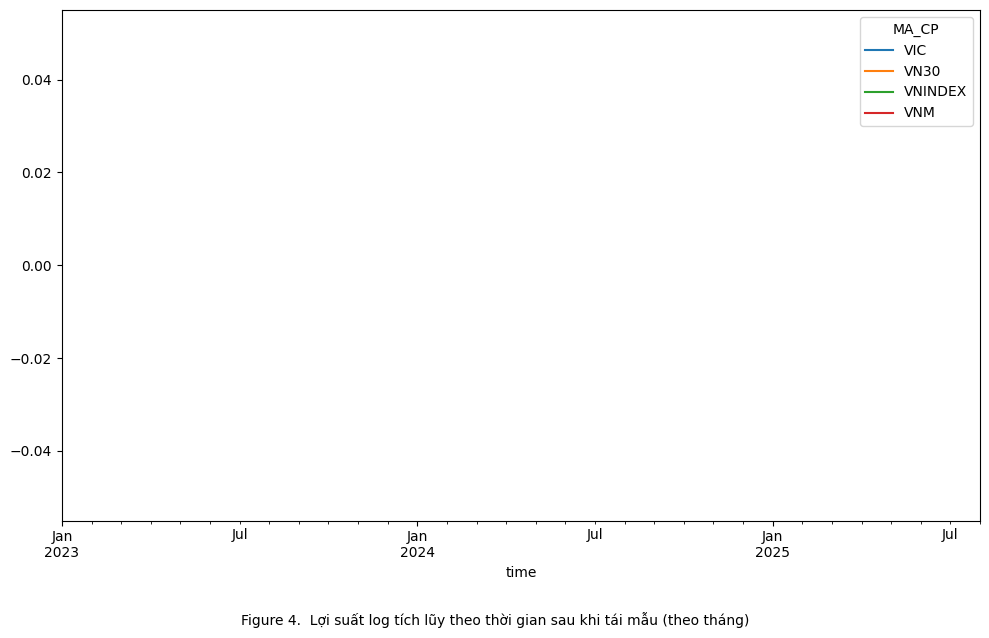

In [33]:
# Vẽ lợi suất log tích luỹ theo thời gian: 
# trước tiên gọi phương thức cumsum(), 
# sau đó áp dụng np.exp() lên kết quả; cuối cùng thực hiện bước tái mẫu (resampling)


(
    data_wide.cumsum().apply(np.exp)                  # Tính log return tích lũy theo thời gian,
        .resample('ME', label='right').last()    # Tái mẫu dữ liệu về tần suất hàng tháng ('1M'),
                                                 # label='right' = gán mốc thời gian cuối tháng,
                                                 # last() = lấy giá trị cuối cùng của mỗi tháng.
        .plot(figsize=(10, 6))                   # Vẽ biểu đồ đường với kích thước (10,6).
)

# Thêm chú thích dưới cùng của figure
plt.figtext(0.5, -0.05,                          # Vị trí caption: x=0.5 (giữa), y=-0.05 (dưới trục X).
            "Figure 4.  Lợi suất log tích lũy theo thời gian sau khi tái mẫu (theo tháng)",  # Nội dung caption.
            wrap=True, horizontalalignment='center', fontsize=10)                # Căn giữa, font chữ 10.

plt.tight_layout()                               # Điều chỉnh bố cục biểu đồ cho gọn gàng, tránh đè chữ.
plt.show()                                       # Hiển thị figure ra màn hình.


# Rolling Statistics (Thống kê lăn)
#### Trong tài chính, có truyền thống sử dụng các thống kê lăn (rolling statistics), thường còn được gọi là các chỉ báo tài chính (financial indicators) hoặc các nghiên cứu tài chính (financial studies).Những thống kê lăn này là công cụ cơ bản cho các nhà phân tích kỹ thuật (financial chartists) và các nhà giao dịch kỹ thuật (technical traders), ví dụ như trong phân tích biểu đồ giá.Phần này chỉ làm việc với một chuỗi thời gian tài chính duy nhất.

In [34]:
# 
sym = 'VNM'

In [35]:
data_2 = pd.DataFrame(data_wide[sym]).dropna()

In [36]:
data_2.head()

,VNM
time,
2023-01-03,68.94
2023-01-04,69.64
2023-01-05,71.31
2023-01-06,70.08
2023-01-09,70.87


In [37]:
data_2.tail()

,VNM
time,
2025-08-25,58.7
2025-08-26,59.7
2025-08-27,60.5
2025-08-28,61.0
2025-08-29,60.3


In [38]:
# Rất đơn giản để lấy số liệu thống kê lăn tiêu chuẩn với pandas:
# Xác định cửa sổ; tức là số lượng giá trị chỉ mục.
window = 10 # 10 dòng tương ứng 10 phiên giao dịch
# Tính giá trị tối thiểu luân phiên.
data_2['min'] = data_2[sym].rolling(window=window).min()
# Tính giá trị trung bình luân phiên.
data_2['mean'] = data_2[sym].rolling(window=window).mean()
# Tính toán độ lệch chuẩn lăn.
data_2['std'] = data_2[sym].rolling(window=window).std()
# Tính giá trị trung bình luân phiên.
data_2['median'] = data_2[sym].rolling(window=window).median()
# ính giá trị lớn nhất luân phiên.
data_2['max'] = data_2[sym].rolling(window=window).max()
#Calculates the exponentially weighted moving average, with decay in terms of a half life of 0.5. 
#data_2['ewma'] = data_2[sym].ewm(halflife=0.5, min_periods=window).mean()

Để có được các chỉ số tài chính chuyên biệt hơn, các gói bổ sung thường cần thiết (ví dụ, xem các biểu đồ tài chính với Khuy măng sét trong "Biểu đồ 2D tương tác" ở trang 195). Các tùy chỉnh cũng có thể dễ dàng được áp dụng thông qua phương thức apply(). Mã sau đây hiển thị một tập hợp con của kết quả và trực quan hóa lựa chọn các số liệu thống kê lăn được tính toán (xem Hình 8-5):

In [39]:
data_2.dropna().head()

,VNM,min,mean,std,median,max
time,,,,,,
2023-01-16,69.73,68.94,70.249,0.763740,70.170,71.31
2023-01-17,71.05,69.64,70.460,0.643998,70.525,71.31
2023-01-18,71.40,69.73,70.636,0.635439,70.830,71.40
2023-01-19,71.40,69.73,70.645,0.646585,70.830,71.40
2023-01-27,70.26,69.73,70.663,0.631437,70.830,71.40


Text(0.5, -0.05, 'Figure 5.   Rolling statistics for minimum, mean, maximum values')

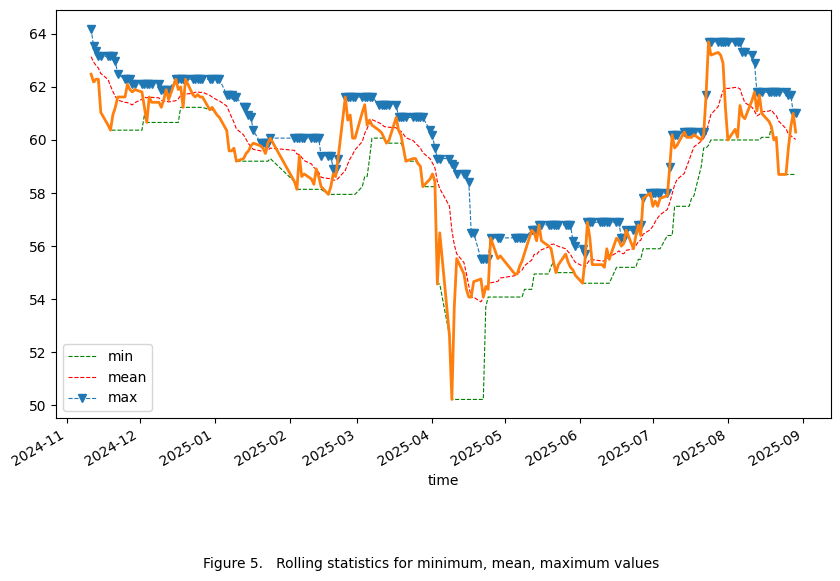

In [40]:
# Vẽ biểu đồ ba thống kê lăn (rolling statistics) cho 200 dòng dữ liệu cuối cùng
# Plots three rolling statistics for the final 200 data rows.
ax = data_2[['min', 'mean', 'max']].iloc[-200:].plot( figsize=(10, 6), style=['g--', 'r--', 'v--'], lw=0.8)
#Thêm dữ liệu chuổi thời gian ban đầu vào biểu đồ
# Adds the original time series data to the plot.
data_2[sym].iloc[-200:].plot(ax=ax, lw=2.0); 
# Thêm chú thích dưới cùng của figure
plt.figtext(0.5, -0.05,
            "Figure 5.   Rolling statistics for minimum, mean, maximum values",
            wrap=True, horizontalalignment='center', fontsize=10)

# Một ví dụ về phân tích kỹ thuật
Thống kê luân phiên là một công cụ chính trong cái gọi là phân tích kỹ thuật cổ phiếu, so với phân tích cơ bản tập trung vào các báo cáo tài chính và vị trí chiến lược của công ty có cổ phiếu đang được phân tích. Một chiến lược giao dịch hàng thập kỷ dựa trên phân tích kỹ thuật là sử dụng hai đường trung bình động đơn giản (SMA). Ý tưởng là nhà giao dịch nên mua cổ phiếu (hoặc công cụ tài chính nói chung) khi SMA ngắn hạn cao hơn SMA dài hạn và nên bán khi điều ngược lại đúng. Các khái niệm có thể được thực hiện chính xác với gấu trúc và khả năng của đối tượng DataFrame. Thống kê luân phiên thường chỉ được tính toán khi có đủ dữ liệu được đưa ra thông số kỹ thuật tham số cửa sổ.

In [41]:
sym = 'VNM'

In [42]:
# chuỗi thời gian SMA chỉ bắt đầu vào ngày có đủ dữ liệu được đưa ra tham số cụ thể
# Tính toán các giá trị cho SMA ngắn hạn.
data_2['SMA1'] = data_2[sym].rolling(window=42).mean()
# Calculates the values for the longer-term SMA.
data_2['SMA2'] = data_2[sym].rolling(window=252).mean()

data_2[[sym, 'SMA1', 'SMA2']].tail()

,VNM,SMA1,SMA2
time,,,
2025-08-25,58.7,60.295238,60.543056
2025-08-26,59.7,60.340476,60.503254
2025-08-27,60.5,60.400000,60.470675
2025-08-28,61.0,60.483333,60.437500
2025-08-29,60.3,60.545238,60.407063


Text(0.5, -0.05, 'Figure 6.  Apple stock price and two simple moving averages')

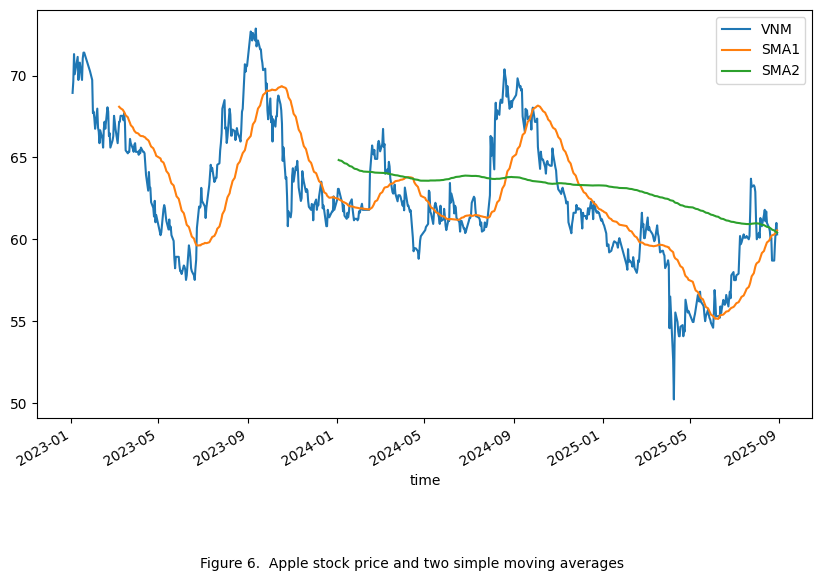

In [43]:
# Visualizes the stock price data plus the two SMA time series.
data_2[[sym, 'SMA1', 'SMA2']].plot(figsize=(10, 6)); 
# Thêm chú thích dưới cùng của figure
plt.figtext(0.5, -0.05,
            "Figure 6.  Apple stock price and two simple moving averages",
            wrap=True, horizontalalignment='center', fontsize=10)

Trong bối cảnh này, SMA chỉ là một phương tiện để đạt được mục đích. Chúng được sử dụng để lấy các vị thế để thực hiện chiến lược giao dịch. Hình 8-7 hình dung một vị thế mua theo giá trị 1 và một vị thế bán bằng giá trị -1. Sự thay đổi vị trí được kích hoạt (trực tiếp) bởi sự giao nhau của hai đường đại diện cho chuỗi thời gian SMA:

Text(0.5, -0.05, 'Figure 7.   Apple stock price, two simple moving averages and positions')

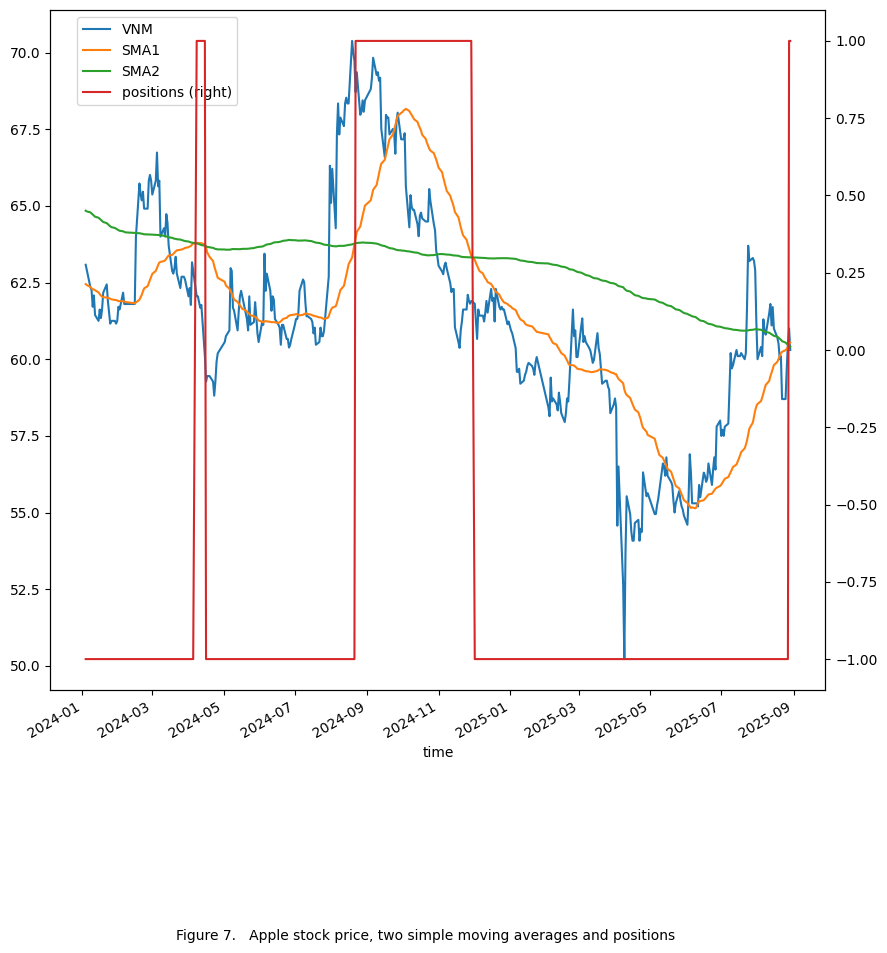

In [44]:
# Only complete data rows are kept.
data_2.dropna(inplace=True)
# If the shorter-term SMA value is greater than the longer-term one …
# … go long on the stock (put a 1).
# Otherwise, go short on the stock (put a -1).
data_2['positions'] = np.where(data_2['SMA1'] > data_2['SMA2'], 1, -1)
# Visualizes the stock price data plus the two SMA time series, and trading strategy
ax = data_2[[sym, 'SMA1', 'SMA2', 'positions']].plot(figsize=(10, 10),secondary_y='positions')
ax.get_legend().set_bbox_to_anchor((0.25, 0.85));
# Thêm chú thích dưới cùng của figure
plt.figtext(0.5, -0.05,"Figure 7.   Apple stock price, two simple moving averages and positions",
            wrap=True, horizontalalignment='center', fontsize=10)


# Correlation Analysis
Như một minh họa thêm về cách làm việc với pandas và dữ liệu chuỗi thời gian tài chính,
hãy xem xét trường hợp của chỉ số chứng khoán S&P 500 và chỉ số biến động VIX. Một thực tế được phong cách hóa là khi S&P 500 tăng, VIX giảm nói chung và ngược lại. Đây là
về mối tương quan chứ không phải nhân quả. Phần này chỉ ra cách đưa ra một số bằng chứng thống kê hỗ trợ cho thực tế cách điệu rằng S&P 500 và VIX có mối tương quan
(cao) có mối tương quan âm.

# The Data
Tập dữ liệu bây giờ bao gồm hai chuỗi thời gian tài chính, cả hai đều được hình dung trong Hình 8-8:

In [45]:
raw = pd.read_csv('data_wide.csv',index_col=0, parse_dates=True)
data_3 = raw[['VNINDEX','VN30']].dropna()

In [46]:
data_3.head()

,VNINDEX,VN30
time,,
2023-01-03,1043.90,1047.25
2023-01-04,1046.35,1050.15
2023-01-05,1055.82,1061.90
2023-01-06,1051.44,1057.40
2023-01-09,1054.21,1061.14


In [47]:
data_3.tail()

,VNINDEX,VN30
time,,
2025-08-25,1614.03,1783.12
2025-08-26,1667.63,1849.05
2025-08-27,1672.78,1848.55
2025-08-28,1680.86,1861.20
2025-08-29,1682.21,1865.38


Text(0.5, -0.05, 'Figure 8.    VNINDEX and VN30 time series data (different subplots)')

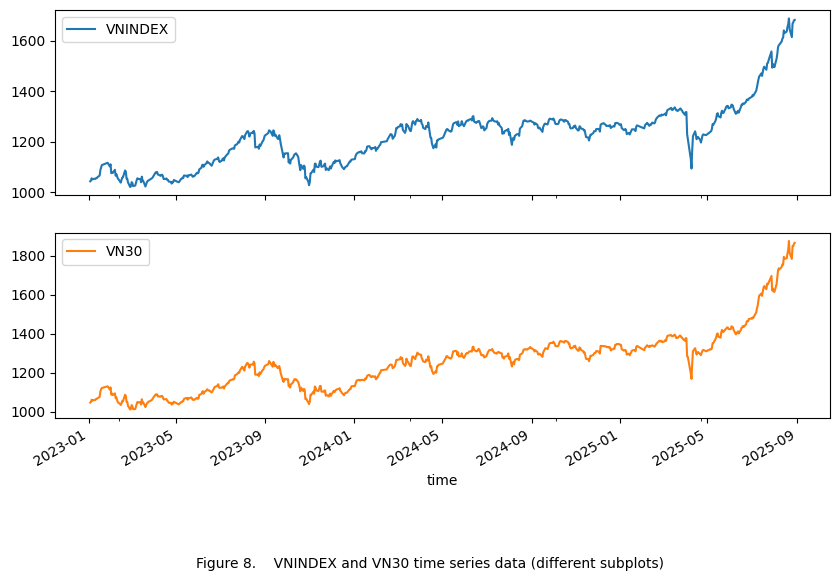

In [48]:
data_3.plot(subplots=True, figsize=(10, 6));
# Thêm chú thích dưới cùng của figure
plt.figtext(0.5, -0.05,"Figure 8.    VNINDEX and VN30 time series data (different subplots)",
            wrap=True, horizontalalignment='center', fontsize=10)


Text(0.5, -0.05, 'Figure 9.S&P 500 and VIX time series data (same plot)')

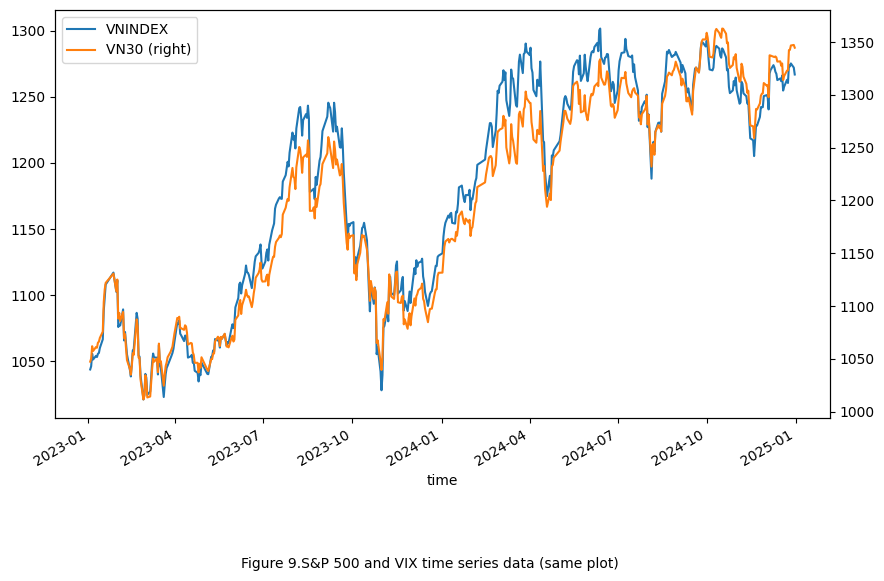

In [49]:
# .loc[:DATE] selects the data until the given value DATE.
data_3.loc[:'2024-12-31'].plot(secondary_y='VN30', figsize=(10, 6));
# Thêm chú thích dưới cùng của figure
plt.figtext(0.5, -0.05,"Figure 9.S&P 500 and VIX time series data (same plot)",
            wrap=True, horizontalalignment='center', fontsize=10)



# Logarithmic Returns
Như đã chỉ ra trước đó, phân tích thống kê nói chung dựa vào lợi nhuận thay vì thay đổi hoàn toàn hoặc thậm chí là giá trị tuyệt đối. Do đó, chúng tôi sẽ tính toán lợi nhuận nhật ký trước khi bất kỳ phân tích nào diễn ra. Hình 8-10 cho thấy sự thay đổi cao của nhật ký trả về theo thời gian. Đối với cả hai chỉ số, cái gọi là "cụm biến động" có thể được phát hiện. Nhìn chung, các giai đoạn biến động cao của chỉ số chứng khoán đi kèm với các hiện tượng tương tự trong chỉ số biến động:

In [50]:
rets = np.log(data_3 / data_3.shift(1))
rets.head()

,VNINDEX,VN30
time,,
2023-01-03,NaN,NaN
2023-01-04,0.002344,0.002765
2023-01-05,0.009010,0.011127
2023-01-06,-0.004157,-0.004247
2023-01-09,0.002631,0.003531


In [51]:
rets.dropna(inplace=True)

In [52]:
rets.head()

,VNINDEX,VN30
time,,
2023-01-04,0.002344,0.002765
2023-01-05,0.009010,0.011127
2023-01-06,-0.004157,-0.004247
2023-01-09,0.002631,0.003531
2023-01-10,-0.000816,-0.000575


Text(0.5, -0.05, 'Figure 10. Log returns of the VNINDEX and VN30 over time')

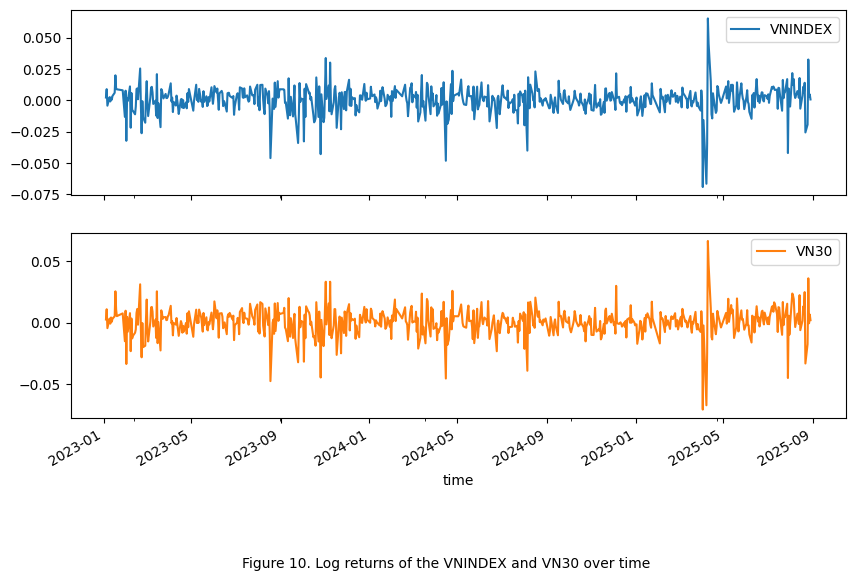

In [53]:
rets.plot(subplots=True, figsize=(10, 6));
# Thêm chú thích dưới cùng của figure
plt.figtext(0.5, -0.05, "Figure 10. Log returns of the VNINDEX and VN30 over time",
            wrap=True, horizontalalignment='center', fontsize=10)



In [54]:
# hệ số tương quan
rets[['VNINDEX','VN30']].corr()       

,VNINDEX,VN30
VNINDEX,1.000000,0.974507
VN30,0.974507,1.000000


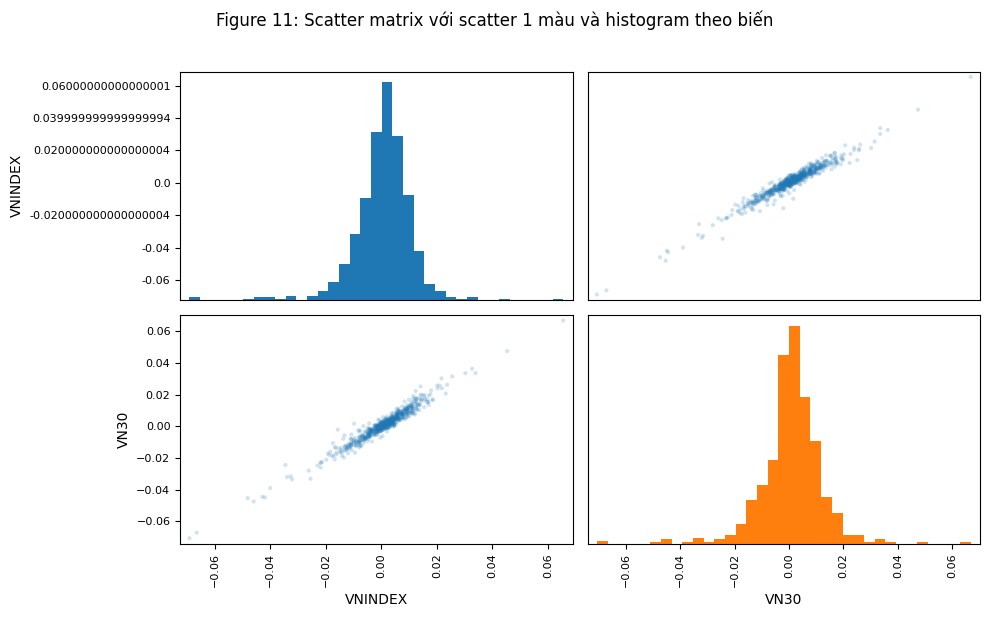

In [55]:
axmat = pd.plotting.scatter_matrix(rets,          # DataFrame 'rets' (mỗi cột là 1 biến, ví dụ: log-returns của các mã). 
                           alpha=0.2,     # Độ trong suốt điểm scatter = 0.2 (giảm chồng lấp, nhìn mật độ rõ hơn).
                           diagonal='hist',          # Đường chéo chính vẽ histogram (thay vì KDE). 
                           hist_kwds={'bins': 35},   # Tham số cho histogram: chia 35 "ngăn" (bins).
                           figsize=(10, 6), # Kích thước figure (rộng 10 inch, cao 6 inch). 
                           color='tab:blue' );    
                                                   # Dấu chấm phẩy ';' để Jupyter không in ra object trả về (chỉ hiển thị hình).
# Tô màu từng histogram trên đường chéo theo biến
palette = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red'][:rets.shape[1]]
for i, col in enumerate(rets.columns):
    ax = axmat[i, i]        # ô đường chéo (hist của biến i)
    for patch in ax.patches:
        patch.set_facecolor(palette[i])
        patch.set_edgecolor('none')

plt.suptitle("Figure 11: Scatter matrix với scatter 1 màu và histogram theo biến", y=1.02)
plt.tight_layout()
plt.show()


# OLS Regression

In [56]:
# hoặc hồi quy để lấy beta
import statsmodels.api as sm
y = rets['VNINDEX']; X = sm.add_constant(rets['VN30'])
sm.OLS(y, X, missing='drop').fit().summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                VNINDEX   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                 1.243e+04
Date:                Mon, 13 Oct 2025   Prob (F-statistic):               0.00
Time:                        15:45:47   Log-Likelihood:                 3052.6
No. Observations:                 661   AIC:                            -6101.
Df Residuals:                     659   BIC:                            -6092.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -7.961e-05   9.33e-05     -0.853      0.394      -0.000       0.000
VN30           0.9177      0.008    111.502      0.000       0.902       0.934
==============================================================================
Omnibus:                      126.902   Durbin-Watson:                   1.793
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              404.941
Skew:                          -0.905   Prob(JB):                     1.17e-88
Kurtosis:                       6.381   Cond. No.                         88.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# 1️⃣ Import thư viện
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2️⃣ Đọc dữ liệu CSV (thay bằng file của bạn)
# File CSV cần có cột Date và các cột giá cổ phiếu như VNINDEX, HPG, VNM, VIC, VCB, FPT
df = pd.read_csv("market.csv", parse_dates=["Date"])
df = df.set_index("Date")  # đặt cột Date làm chỉ số thời gian

# 3️⃣ Tính log-return (để tương quan phản ánh biến động lợi suất chứ không phải giá)
log_return = df.apply(lambda x: np.log(x / x.shift(1)))  # log-return = ln(Pt / Pt-1)
log_return = log_return.dropna()  # bỏ dòng đầu bị NA

# 4️⃣ Tạo ma trận tương quan (Correlation Matrix)
correlation_matrix = log_return.corr()  # hệ số tương quan Pearson giữa các cổ phiếu

# 5️⃣ Vẽ heatmap hiển thị ma trận tương quan
plt.figure(figsize=(8, 6))  # kích thước biểu đồ
sns.heatmap(
    correlation_matrix,
    annot=True,          # hiển thị hệ số tương quan trên từng ô
    cmap="coolwarm",     # màu: đỏ - dương, xanh - âm
    fmt=".2f",           # hiển thị 2 chữ số thập phân
    linewidths=0.5,      # đường ngăn giữa các ô
    cbar=True            # thanh màu bên phải
)
plt.title("📊 Ma trận tương quan giữa các cổ phiếu", fontsize=13)
plt.tight_layout()
plt.show()

# 6️⃣ (Tuỳ chọn) In ma trận ra màn hình
print("=== Ma trận tương quan giữa các cổ phiếu ===")
print(correlation_matrix.round(2))


In [ ]:
# ============================================
# PHÂN TÍCH TƯƠNG QUAN CÁC CỔ PHIẾU
# ============================================

# 1️⃣ Import thư viện cần thiết
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2️⃣ Đọc dữ liệu CSV (thay 'market.csv' bằng file của bạn)
# File cần có cột 'Date' và các cột giá cổ phiếu như VNINDEX, HPG, VNM, VIC, VCB, FPT
df = pd.read_csv("market.csv", parse_dates=["Date"])
df = df.set_index("Date")  # đặt cột Date làm index thời gian

# 3️⃣ Tính ma trận tương quan giữa các cột
correlation_matrix = df.corr()

# 4️⃣ Trực quan hóa ma trận tương quan bằng Seaborn
plt.figure(figsize=(8, 6))  # Kích thước biểu đồ
sns.heatmap(
    correlation_matrix,      # Ma trận tương quan
    annot=True,              # Hiển thị giá trị hệ số trong từng ô
    cmap="coolwarm",         # Bảng màu (đỏ–xanh)
    fmt=".2f",               # Hiển thị 2 chữ số thập phân
    linewidths=0.5,          # Độ dày đường ngăn cách
    cbar=True                # Hiển thị thanh màu bên phải
)

# 5️⃣ Thêm tiêu đề và hiển thị biểu đồ
plt.title("📊 Ma trận tương quan giữa các cổ phiếu", fontsize=13)
plt.tight_layout()
plt.show()
